# ML Driven MOF PFAS Adsorbent Discovery

### Set-up

In [1]:
import sys
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting data
import os
#import re
np.random.seed(42)

In [2]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def scatter_with_ols(x, y, poly_deg=1, x_label=None, y_label=None, title=None):
    """
    Create a scatter plot of x vs y with an OLS polynomial fit and R-squared.
    
    Parameters
    ----------
    x, y : array-like
        Input feature arrays of equal length.
    poly_deg : int, optional (default=1)
        Polynomial degree for OLS fit (1 = linear, up to 3).
    x_label, y_label : str, optional
        Axis labels.
    title : str, optional
        Plot title.
    """
    if poly_deg < 1 or poly_deg > 3:
        raise ValueError("poly_deg must be 1, 2, or 3")

    x = np.asarray(x)
    y = np.asarray(y)

    # Polynomial OLS fit
    coeffs = np.polyfit(x, y, poly_deg)
    poly = np.poly1d(coeffs)

    # Predictions (sorted for smooth curve)
    x_sorted = np.sort(x)
    y_pred_sorted = poly(x_sorted)
    y_pred = poly(x)

    # R-squared
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - ss_res / ss_tot

    # Plot
    plt.figure()
    plt.scatter(x, y)
    plt.plot(x_sorted, y_pred_sorted)
    
    plt.xlabel(x_label if x_label else "X")
    plt.ylabel(y_label if y_label else "Y")
    plt.title(title if title else f"Scatter Plot with Degree-{poly_deg} OLS Fit")

    plt.text(
        0.05, 0.95,
        f"Degree = {poly_deg}\n$R^2 = {r_squared:.3f}$",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    plt.show()

    return r_squared


In [25]:
folder_path = r'../data/'
dfs = {}
for filename in os.listdir(folder_path):
    #print(filename)
    if filename.startswith('Descriptors') and filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)

        pfas_name = filename.removeprefix('Descriptors-').removesuffix('.csv')
        # pfas_name = filename.replace('Descriptors-', '')
        # pfas_name = pfas_name.replace('.csv', '')
        print(pfas_name)
        dfs[pfas_name] = df

PFOA
PFOS


In [29]:
for filename in os.listdir(folder_path):
    #print(filename)
    if filename.startswith('Test') and filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        mof_name = filename.removeprefix('Test_').removesuffix('.csv')
        print(mof_name)
        dfs[mof_name] = df

coremof
coremof_FSR
coremof_Ion
coremof_NCR
coremof_occupancy


In [31]:
dfs.keys()


dict_keys(['PFOA', 'PFOS', 'coremof', 'coremof_FSR', 'coremof_Ion', 'coremof_NCR', 'coremof_occupancy'])

### Adsorbent Features

The following adsorbent features are used:

- **Density**: Framework density of the MOF, reflecting how compact or open the porous structure is.
- **PLD (Pore Limiting Diameter)**: Diameter of the largest spherical probe that can pass through the narrowest pore window, indicating if PFAS can **enter** pore.
- **LCD (Largest Cavity Diameter)**: Diameter of the largest spherical cavity within the framework, indicating if the PFAS can **fit** comfortably.
- **GSA (Geometric Surface Area)**: Total internal surface area of the framework accessible to a probe molecule, representing available adsorption surface.
- **Void Fraction**: Fraction of the unit cell volume that is empty space, serving as a measure of porosity.
- **Pore Volume**: Total accessible pore volume per unit mass of the framework, serving as a proxy for adsorption capacity.


# PART-A: Data Filtering

In [33]:
numeric_df = dfs['PFOA'].select_dtypes(include = 'number').drop(columns = 'Serial')
#numeric_df.describe()

summary = pd.DataFrame({
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mean': numeric_df.mean(),
    'range': numeric_df.max() - numeric_df.min()
})

summary

,min,max,mean,range
Density,0.457460,2.022730,1.107506,1.565270
PLD,0.621250,28.351690,6.997557,27.730440
LCD,1.497060,34.154090,13.450891,32.657030
GSA,2178.080000,5397.310000,3643.515217,3219.230000
Void_Fraction,0.186605,0.825575,0.596608,0.638970
Pore_Volume,0.099996,1.804690,0.728935,1.704694


In [34]:
numeric_df = dfs['PFOS'].select_dtypes(include = 'number').drop(columns = 'Serial')
#numeric_df.describe()

summary = pd.DataFrame({
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mean': numeric_df.mean(),
    'range': numeric_df.max() - numeric_df.min()
})

summary

,min,max,mean,range
Density,0.486040,2.022730,1.049382,1.536690
PLD,1.082140,30.988490,9.003282,29.906350
LCD,2.718190,32.023940,13.040171,29.305750
GSA,2383.430000,4879.000000,3739.476154,2495.570000
Void_Fraction,0.281035,0.823815,0.612963,0.542780
Pore_Volume,0.171321,1.691350,0.809888,1.520029


In [89]:
numeric_df = dfs['coremof_FSR'].select_dtypes(include = 'number').drop(columns = 'Serial')
#numeric_df.describe()

summary = pd.DataFrame({
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mean': numeric_df.mean(),
    'range': numeric_df.max() - numeric_df.min()
})

summary

,min,max,mean,range
Density,0.175207,3.47805,1.226782,3.302843
PLD,1.993290,29.43580,4.943792,27.442510
LCD,2.733440,38.91559,6.872582,36.182150
GSA,2028.420000,5460.34000,4120.357601,3431.920000
Void_Fraction,0.265520,0.92854,0.543300,0.663020
Pore_Volume,0.095337,5.29967,0.513631,5.204333
UnitCell_MW_g_mol,332.861000,28518.98400,2873.974074,28186.123000


We see a few relationships between features:

In [104]:
#Set PFAS type
PFAS = "PFOA" #"coremof"

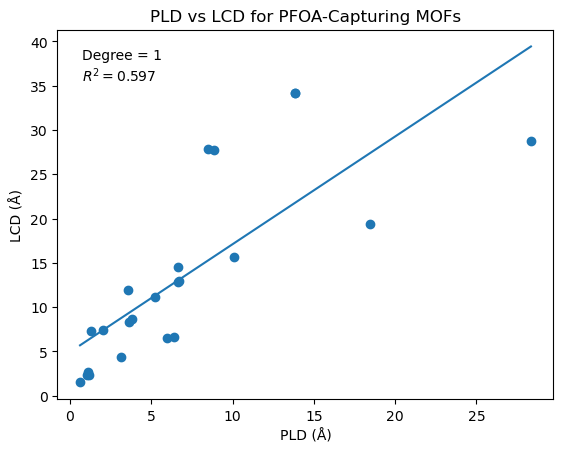

In [106]:
feature1 = "PLD"
feature2 = "LCD"
r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], 1, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")


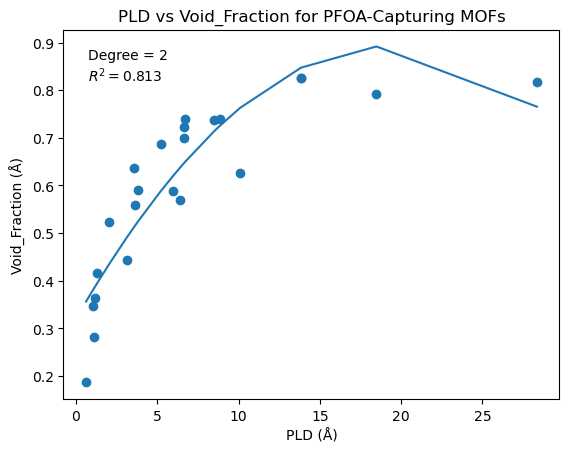

In [107]:
feature1 = "PLD"
feature2 = "Void_Fraction"
r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], 2, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")


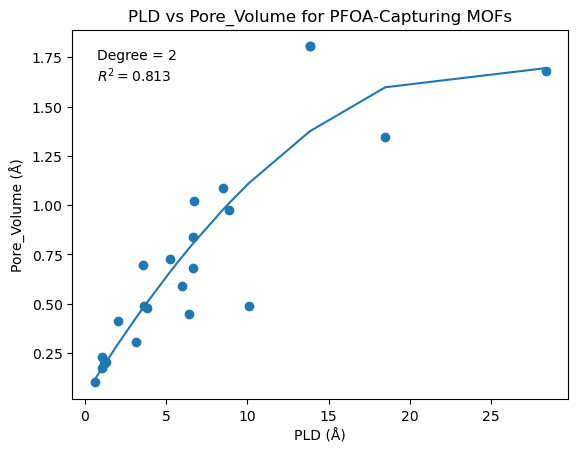

In [109]:
feature1 = "PLD"
feature2 = "Pore_Volume"
r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], 2, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")

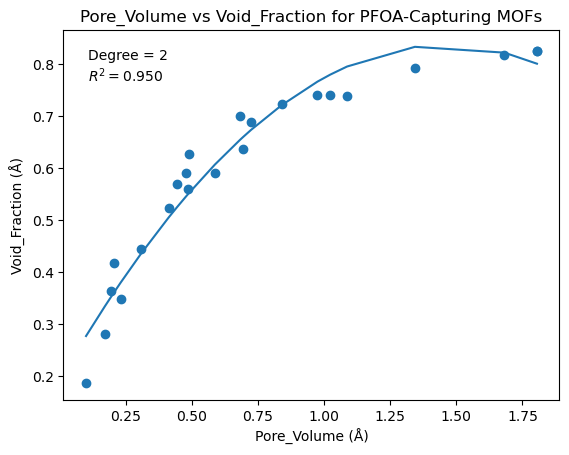

In [110]:
feature1 = "Pore_Volume"
feature2 = "Void_Fraction"

r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], 2, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")

### Key Takeaways

- A large portion of the central range of void fractions appears compatible with PFAS adsorption.  
- PFAS-capable MOFs do not occupy a single geometric niche; for example, a high LCD can compensate for a low PLD.  
- These observations suggest that simple threshold-based filtering is insufficient, and a more capable method is needed—one that considers the overall geometric position of each MOF in feature space.


# One Class SVM

- This method fits a region rather than a function. (We do not have -ve data so a logistic regression doesnt work. We do not have a scaler prediction so regression does not work).
- Can we not generate -ve samples? Will introduce false negatives.
- i.e. what is the smallest region that encloses most of the data
- We are then able to say if a new MOF is within this learned envelop or outside it.
- While an SVM places a boundary furthest from +ve and -ve data (a border), ON-SVM places a boundary as tight as possible around positives.

In [50]:
# Core descriptor set
core_features = [
    "PLD",
    "LCD",
    "GSA",
    "Void_Fraction",
    "Pore_Volume",
    # "Density",  # uncomment later for sensitivity analysis
]

# Select PFAS dataset
df = dfs["PFOA"].copy()

# Extract feature matrix
X = df[core_features].values


In [114]:
ocsvm = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ocsvm", OneClassSVM(
            kernel="rbf",
            nu=0.20,      # ~nu% of points allowed outside boundary
            gamma="scale" # reasonable default; refine later
        ))
    ]
)
nu_hypP = ocsvm.named_steps["ocsvm"].nu
nu_hypP

0.2

In [116]:
nu_hypP = ocsvm.named_steps["ocsvm"].nu
nu_hypP

0.2

In [118]:
ocsvm

Pipeline(steps=[('scaler', StandardScaler()), ('ocsvm', OneClassSVM(nu=0.2))])

In [120]:
ocsvm.fit(X)

Pipeline(steps=[('scaler', StandardScaler()), ('ocsvm', OneClassSVM(nu=0.2))])

In [122]:
rho = -ocsvm.named_steps["ocsvm"].intercept_[0]
max_possible_score = 1 - rho

print("rho:", rho)
print("Theoretical max score:", max_possible_score)

rho: 1.0398970850023506
Theoretical max score: -0.03989708500235056


In [124]:
# Decision function: higher = more confidently inside the region
scores = ocsvm.decision_function(X)

# Binary labels: +1 = inlier, -1 = outlier
labels = ocsvm.predict(X)

df_results = df.copy()
df_results["ocsvm_score"] = scores
df_results["ocsvm_label"] = labels


In [126]:
df_results.sort_values("ocsvm_score", ascending=False)

,Serial,Name,Density,PLD,LCD,GSA,Void_Fraction,Pore_Volume,ocsvm_score,ocsvm_label
17,18,ZIF-7,1.44353,3.12929,4.34999,3930.34,0.444385,0.307846,0.174089,1
14,15,MIL-101(Cr)-NH2,1.86975,1.16138,2.33487,4245.26,0.363220,0.194262,0.167245,1
11,12,MIL-96(Al),1.15105,3.62904,8.33017,3579.42,0.559655,0.486214,0.157188,1
7,8,PCN-1002,1.26921,2.05535,7.42090,3526.25,0.523740,0.412650,0.149558,1
0,1,UiO-66,1.23478,3.82175,8.70307,2920.55,0.590055,0.477861,0.130723,1
22,23,Ce-BTC,1.28067,6.39825,6.62027,3272.51,0.569755,0.444890,0.112964,1
2,3,UiO-66-F4,1.64040,1.08214,2.71819,4812.39,0.281035,0.171321,0.108609,1
10,11,MIL-53(Al)-as,1.00403,5.95247,6.51942,3990.86,0.589390,0.587024,0.093254,1
8,9,DUT-67,1.02671,6.62955,14.50667,2708.09,0.699795,0.681588,0.077175,1
20,21,HKUST-1,0.94885,5.21063,11.11888,3706.74,0.687340,0.724390,0.070330,1


### Results interpretation:
- only the relative scores are important
- can not iterpret the absoute values (this is not parametric)

### Training with Density

In [128]:
core_plus_density_features  = core_features + ["Density"]
X_density = df[core_plus_density_features].values

ocsvm_density = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ocsvm", OneClassSVM(
            kernel="rbf",
            nu=nu_hypP,
            gamma="scale"
        ))
    ]
)

ocsvm_density.fit(X_density)

df_results["ocsvm_score_with_density"] = ocsvm_density.decision_function(X_density)


In [130]:
df_results.sort_values("ocsvm_score")


,Serial,Name,Density,PLD,LCD,GSA,Void_Fraction,Pore_Volume,ocsvm_score,ocsvm_label,ocsvm_score_with_density
18,19,ZIF-8,0.91650,3.57948,11.98309,4995.87,0.635990,0.693935,-0.000417,-1,0.000057
16,17,MIL-101 (Fe),0.45746,13.84071,34.15409,3804.83,0.825575,1.804690,-0.000284,-1,-0.000061
13,14,MIL-101(Cr),0.45746,13.84071,34.15409,3804.83,0.825575,1.804690,-0.000284,-1,-0.000061
5,6,MOF-808,1.28410,10.09089,15.63835,2178.08,0.626260,0.487702,-0.000183,-1,-0.000117
6,7,PCN-999,0.58974,18.48015,19.43968,3429.84,0.792225,1.343360,-0.000173,-1,0.029163
15,16,MIL-100 (Fe),0.75909,8.84616,27.76155,3270.98,0.740035,0.974893,0.000015,1,0.000150
9,10,NU-1000,0.48604,28.35169,28.81297,3605.15,0.817445,1.681850,0.000162,1,-0.000241
19,20,ZIF-L,1.50141,1.07376,2.36447,5397.31,0.347035,0.231140,0.000162,1,-0.000102
21,22,Mn-BTC,1.86613,0.62125,1.49706,4111.54,0.186605,0.099996,0.000221,1,-0.000117
3,4,UiO-67,0.72259,6.73387,12.96894,3474.86,0.739285,1.023110,0.000246,1,0.000305


### Plotting training
- Plot the exact OC-SVM boundary is *impossible* because it lives in 5-6 dimensional (features) space further increased by the kernel induced space.

So the objective becomes to "Visualize how points relate to the OC-SVM decision function in a meaningful 2D projection":

Explanation.

We have two optoins:
  - visualise with first 2 pca, or
  - Decision boundaries were visualized by evaluating the OC-SVM on 2D slices of the scaled descriptor space, constructed by varying selected feature pairs while fixing all remaining descriptors at their mean values.”


In [139]:
#Select Plot space
plot_space = 1 # plot_space: 1 --> PCA plo; 2--> original features
feat_x = 0  # e.g. PLD
feat_y = 1  # e.g. LCD

if plot_space == 1:
    X_feature = X_pca1
    Y_feature = X_pca2
else: 
    X_feature = X_scaled[:, feat_x]
    Y_feature = X_scaled[:, feat_y]
    


NameError: name 'X_pca1' is not defined

In [ ]:
#Build a grid in selected space

x_min, x_max = X_feature.min() - 1, X_feature.max() + 1
y_min, y_max = Y_feature.min() - 1, Y_feature.max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

#grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_2d = np.c_[xx.ravel(), yy.ravel()]

In [135]:
# Back to scaled feature space
#grid_scaled = pca.inverse_transform(grid__2d)
# Back to scaled feature space (version that allows to plot original features)
if plot_space == 1:
    grid_scaled = pca.inverse_transform(grid_2d)
else:
    # Start from mean of scaled data: 
    grid_scaled = np.tile(X_scaled.mean(axis=0), (grid_2d.shape[0], 1)) 

    # Insert grid values into the selected feature dimensions
    grid_scaled[:, feat_x] = grid_2d[:, 0]
    grid_scaled[:, feat_y] = grid_2d[:, 1]

# Evaluate OC-SVM decision function
Z = svm.decision_function(grid_scaled)
Z = Z.reshape(xx.shape)


NameError: name 'pca' is not defined

In [137]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca1 = X_pca[:, 0]
X_pca2 = X_pca[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)


NameError: name 'X_scaled' is not defined

In [ ]:
type(df_results['PLD'].to_numpy())
#type(X_feature)

In [ ]:
scaler = ocsvm.named_steps["scaler"]
svm = ocsvm.named_steps["ocsvm"]
nu = ocsvm.named_steps["ocsvm"].nu
X_scaled = scaler.transform(X)


In [ ]:
X_scaled

### Plot Training

In [ ]:
#import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Decision boundary (score = 0)
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

# Filled contours (optional)
plt.contourf(xx, yy, Z, levels=50, alpha=0.3)

# Plot points
labels = ocsvm.predict(X)
plt.scatter(
    X_feature, Y_feature,
    c=labels, cmap="coolwarm", edgecolors="k"
)

# Annotate MOFs
for i, name in enumerate(df["Name"]):
    plt.text(X_feature[i], Y_feature[i], name, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"OC-SVM PFAS–MOF Region (PCA projection){nu}")

plt.savefig(rf"..\Notebooks\OCSVM-Region-nu{nu}.png", 
            format='png', 
            bbox_inches='tight', 
            transparent=True,
            pad_inches=0)
plt.show()


### Some more thoughts:

- Material Identity discovery vs material property prediciton
- i.e. we are answering "Does this look like the kind of MOFs that work"? Not anwering "How well will this MOF work".

In [ ]:
X_pca

# Testing

#### Test: Inference


- *Output Score Intepretation*: A signed geometric margin measuring how strongly a structure belongs to the learned PFAS-compatible descriptor region.
$$
f(x) = \sum_{i=1}^{n} \alpha_i \, K(x_i, x\prime) - \rho
$$
where:
$x_i$ are known PFAS MOF descriptors, (one per training sample - not feature - nice feature, see 'Representer Theorem').
$x\prime$ is the candidate MOF descriptor to be evaluated.
 
- *Parameter Intepretation*: An upper bound on the fraction of training points allowed to be outside (small 'nu' --> model tries to include all point in training --> large permissive boundary).
- Standardisation centres all observation around mean with a 'few' std devs of data on either side. While this does not mean distance between two points is zero, it does imply "small" distance scores for points within the learned region. 

- Note, the kernel used is the RBF kernel that allows non-linear regions:
$$
K(x, x\prime) = \exp\left(-\gamma \|x - x\prime\|^2\right)
$$



In [ ]:
# Extract and scale the Test set
X_coremof_core = dfs["coremof"][core_features].values
X_coremof_core_scaled = scaler.transform(X_coremof_core)

# X_coremof_core_plus_density = dfs["coremof"][core_plus_density_features].values
# X_coremof_core_plus_density_scaled = scaler_core_plus_density.transform(
#     X_coremof_core_plus_density
# )


In [ ]:
dfs["coremof"][core_features]

In [ ]:
# Get anomaly scores 
scores_core = ocsvm.decision_function(X_coremof_core)

# scores_core_plus_density = model_core_plus_density.decision_function(
#     X_coremof_core_plus_density_scaled
# )

In [ ]:
# Get binary in/out classification
labels_core = ocsvm.predict(X_coremof_core_scaled)
# labels_core_plus_density = model_core_plus_density.predict(
#     X_coremof_core_plus_density_scaled
# )


In [ ]:
dfs["coremof"]["score_core"] = scores_core
dfs["coremof"]["label_core"] = labels_core

# dfs["coremof"]["score_core_plus_density"] = scores_core_plus_density
# dfs["coremof"]["label_core_plus_density"] = labels_core_plus_density

In [ ]:
results_sorted = dfs["coremof"].sort_values("score_core", ascending=False)
results_sorted

In [ ]:
# output_folder = r'..\data'

# if not os.path.exists(output_folder):
#     os.makedirs(output_folder)
# file_path = os.path.join(output_folder, f"coremof_ocsvm_results_nu{nu_hypP}.csv")

# results_sorted.to_csv(file_path, index=False)

#### Testing: comparing models
- Important ..

In [ ]:
results_sorted_05

#### Testing: Plotting
- Important to remember not to refit PCA on coremof

In [ ]:
# Use the SAME scaler from pipeline
scaler = ocsvm.named_steps["scaler"]

X_coremof_scaled = scaler.transform(X_coremof_core)

# Project into PCA space
X_coremof_pca = pca.transform(X_coremof_scaled)
    
X_coremof_pca1 = X_coremof_pca[:, 0]
X_coremof_pca2 = X_coremof_pca[:, 1]

In [ ]:
# # Get labels for coremof
# labels_core = ocsvm.predict(X_coremof_core)

# # Overlay coremof points
# plt.scatter(
#     X_coremof_pca1,
#     X_coremof_pca2,
#     c=labels_core,
#     cmap="coolwarm",
#     marker="x",
#     s=40,
#     alpha=0.7
# )


In [ ]:
# Training data
plt.figure(figsize=(8, 6))

# Decision boundary (score = 0)
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

# Filled contours (optional)
plt.contourf(xx, yy, Z, levels=50, alpha=0.3)

# plt.scatter(X_feature, Y_feature,
#             c=labels,
#             cmap="coolwarm",
#             edgecolors="k",
#             s=80,
#             label="Training MOFs")

# Coremof data
plt.scatter(X_coremof_pca1,
            X_coremof_pca2,
            c=labels_core,
            cmap="coolwarm",
            marker="o",
            s=40,
            alpha=0.7,
            label="CoreMOF Screening")

plt.legend()
plt.title(f"OC-SVM Test Region (PCA projection){nu}")
# plt.savefig(rf"..\Notebooks\OCSVM-Test-nu{nu}.png", 
#             format='png', 
#             bbox_inches='tight', 
#             transparent=True,
#             pad_inches=0)
plt.show()


In [ ]:
plt.figure(figsize=(8, 6))

# Decision boundary (score = 0)
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

# Filled contours (optional)
plt.contourf(xx, yy, Z, levels=50, alpha=0.3)

# Plot points
labels = ocsvm.predict(X)
plt.scatter(
    X_feature, Y_feature,
    c=labels, cmap="coolwarm", edgecolors="k"
)

# Annotate MOFs
for i, name in enumerate(df["Name"]):
    plt.text(X_feature[i], Y_feature[i], name, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"OC-SVM PFAS–MOF Region (PCA projection){nu}")

# plt.savefig(rf"..\Notebooks\OCSVM-Region-nu{nu}.png", 
#             format='png', 
#             bbox_inches='tight', 
#             transparent=True,
#             pad_inches=0)
plt.show()

In [ ]:
result_df_15